In [1]:
from google.colab import files
uploaded=files.upload()


MessageError: TypeError: Cannot read properties of undefined (reading 'next')

In [ ]:
import zipfile
with zipfile.ZipFile("Illegal parking detection 1.v1i.yolov9 (1).zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")
print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
data = '''
path: /content/dataset
train: train/images
val: valid/images
test: test/images
nc: 2
names:
  0: Legalparking
  1: illegalparking
'''
with open('/content/dataset/data.yaml', 'w') as f:
    f.write(data)

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

In [ ]:
model = YOLO("yolov9c.pt")

In [ ]:
results = model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

In [ ]:
metrics = model.val()

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv9c summary (fused): 156 layers, 25,320,790 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1230.2±430.0 MB/s, size: 40.4 KB)
val: Scanning /content/dataset/valid/labels.cache... 216 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 216/216 56.6Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 212, len(boxes) = 388. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.2it/s 11.4s
                   all        216        388       0.58      0.732      0.645      0.389
          Legalparking        130        215      0.495      0.666      0.518       0.33
        illegalparking        151    

In [ ]:
model.predict(
    source="/content/dataset/train/images/b23_jpg.rf.8ada81d2f014ea41e96dd7d52c2ffb60.jpg",
    conf=0.5,
    save=True
)


image 1/1 /content/dataset/train/images/b23_jpg.rf.8ada81d2f014ea41e96dd7d52c2ffb60.jpg: 640x640 1 illegalparking, 48.7ms
Speed: 3.0ms preprocess, 48.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Legalparking', 1: 'illegalparking'}
 obb: None
 orig_img: array([[[ 3,  8,  7],
         [13, 18, 17],
         [12, 17, 16],
         ...,
         [31, 33, 33],
         [31, 33, 33],
         [39, 41, 41]],
 
        [[ 6, 11, 10],
         [12, 17, 16],
         [10, 15, 14],
         ...,
         [33, 35, 35],
         [33, 35, 35],
         [40, 42, 42]],
 
        [[11, 16, 15],
         [10, 15, 14],
         [ 8, 13, 12],
         ...,
         [36, 38, 38],
         [36, 38, 38],
         [41, 43, 43]],
 
        ...,
 
        [[44, 48, 49],
         [44, 48, 49],
         [43, 47, 48],
         ...,
         [40, 42, 43],
         [41, 43, 44],
         [41, 43, 44]],
 
        [[44, 48, 49],
         [44, 48, 49],
         [43, 47, 48],
         ...,
         [39, 41, 42],
         [39, 41, 42],
         [39, 41, 42]],
 


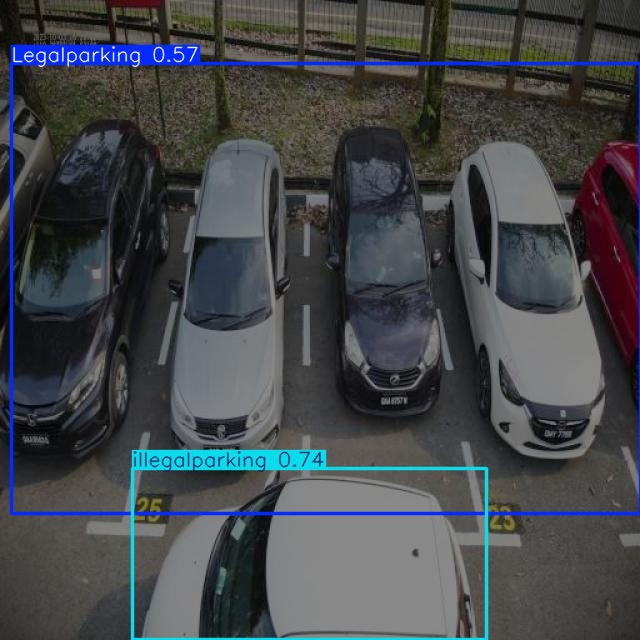

In [ ]:
from IPython.display import Image
Image(filename='/content/runs/detect/predict/b23_jpg.rf.8ada81d2f014ea41e96dd7d52c2ffb60.jpg')